# German Traffic Sign Recognition: CNN vs Vision Transformer

This notebook implements and compares two deep learning architectures — a **Convolutional Neural Network (CNN)** and a **Vision Transformer (ViT)** — for classifying 43 categories of German traffic signs using the [GTSRB dataset](https://www.kaggle.com/datasets/harbhajansingh21/german-traffic-sign-dataset).

**Pipeline overview:**
1. Dataset download & loading
2. Exploratory Data Analysis (EDA)
3. Data preprocessing & augmentation
4. CNN — build, train, tune, evaluate
5. ViT — build, train, tune, evaluate
6. Comparative analysis

> **Note on compute constraints:** The ViT experiments were limited by Google Colab free-tier GPU quota. Each ViT epoch takes ~120s vs ~6s for the CNN, meaning the ViT hyperparameter search could only complete 3 of the intended 10 trials before GPU time ran out. The final ViT was also cut short by early stopping at epoch 16/20. With more compute, the ViT would likely close the gap with the CNN significantly.

In [1]:
!pip install opendatasets

## 1. Setup

### 1.1 Install Dependencies

`opendatasets` is used to download the dataset directly from Kaggle. You will need your Kaggle API credentials (username + key) when prompted.

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/harbhajansingh21/german-traffic-sign-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hajjjjjjj
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/harbhajansingh21/german-traffic-sign-dataset


100%|██████████| 118M/118M [00:00<00:00, 857MB/s] 

### 1.2 Download Dataset

Downloads the GTSRB dataset (~118 MB) from Kaggle into the `/content/german-traffic-sign-dataset/` directory.

In [3]:
import pandas as pd
data = pd.read_csv("/content/german-traffic-sign-dataset/signname.csv")

### 1.3 Load Sign Name Mapping

Loads `signname.csv` which maps each class ID (0–42) to its human-readable traffic sign name.

In [4]:
# Loading datasets
training_file = '/content/german-traffic-sign-dataset/train.p'
validation_file='/content/german-traffic-sign-dataset/valid.p'
testing_file = '/content/german-traffic-sign-dataset/test.p'


### 1.4 Define Dataset File Paths

The dataset is stored as serialised pickle files — one each for training, validation, and test splits.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Load Splits

Deserialises the pickle files into NumPy arrays. Each split contains `features` (image arrays) and `labels` (integer class IDs).

In [5]:
# load training, validation, and test datasets
import pickle

with open(training_file, mode='rb') as f:
    training_data = pickle.load(f)

with open(validation_file, mode='rb') as f:
    validation_data = pickle.load(f)

with open(testing_file, mode='rb') as f:
    testing_data = pickle.load(f)

### 2.2 Dataset Summary

Prints the number of samples in each split and confirms the image shape (32×32 RGB) and label dtype.

The dataset is split roughly 68% train / 9% validation / 25% test, which is a reasonable distribution for this task.

In [6]:
import numpy as np

# Explores Dataset Structure
x_train, y_train = training_data['features'], training_data['labels']
x_valid, y_valid = validation_data['features'], validation_data['labels']
x_test, y_test = testing_data['features'], testing_data['labels']

n_train = len(y_train)
n_valid = len(y_valid)
n_test = len(y_test)

image_shape = x_train[0].shape
label_dtype = y_train.dtype

print("Number of training examples =", n_train)
print("Number of validation examples =", n_valid)
print("Number of testing examples =", n_test)
print("Image data shape =", image_shape)
print("Label data type =", label_dtype)

Number of training examples = 34799
Number of validation examples = 4410
Number of testing examples = 12630
Image data shape = (32, 32, 3)
Label data type = uint8


### 2.3 Sample Visualisation

Displays 3 random sample images per class (43 classes × 3 = 129 images). The grid reveals key challenges in this dataset: many images are small, dark, or motion-blurred, and signs of the same class can look quite different depending on lighting and viewing angle. This motivates the use of data augmentation during training.

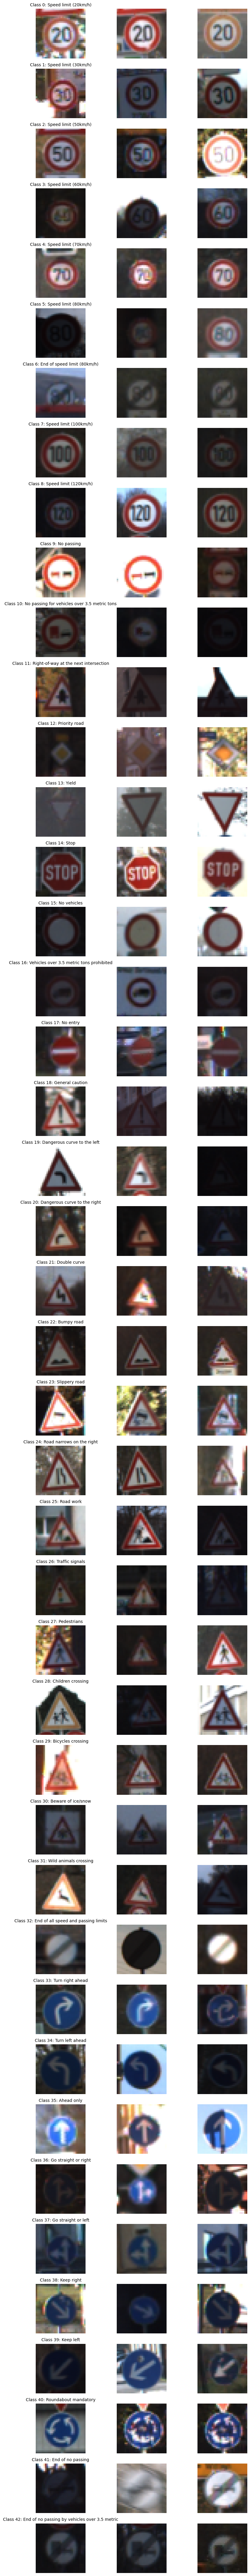

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

num_samples_per_class = 3
num_classes = len(data)

# Calculate the number of rows and columns for the subplot grid
n_cols = num_samples_per_class
n_rows = num_classes

plt.figure(figsize=(n_cols * 3, n_rows * 2)) # Adjust figure size

for class_id in range(num_classes):
    # Get indices of images belonging to the current class in the training set
    class_indices = np.where(y_train == class_id)[0]

    # Select a few random indices from the class indices
    selected_indices = random.sample(list(class_indices), min(num_samples_per_class, len(class_indices)))

    # Get the sign name for the class ID
    sign_name = data[data['ClassId'] == class_id]['SignName'].iloc[0]

    # Display the sample images for the current class in a row
    for i, index in enumerate(selected_indices):
        image = x_train[index]
        plt.subplot(n_rows, n_cols, class_id * n_cols + i + 1)
        plt.imshow(image)
        if i == 0: # Add title only to the first image in the row
            plt.title(f"Class {class_id}: {sign_name}", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

### 2.4 Image Dimension Analysis

Verifies that all images across all splits share the same spatial dimensions (32×32). Inconsistent sizes would require resizing before training. The low resolution (32×32) is worth noting — it limits the amount of fine-grained detail available to both models, and is one reason the ViT (which benefits from higher resolution patches) is at a disadvantage here.

In [7]:
import numpy as np

def analyze_image_dimensions(images, dataset_name):
    """Calculates and prints image height, width, and aspect ratio statistics."""
    heights = [img.shape[0] for img in images]
    widths = [img.shape[1] for img in images]
    aspect_ratios = [img.shape[1] / img.shape[0] for img in images]

    print(f"\nAnalyzing {dataset_name}...")
    print(f"  Min height: {np.min(heights)}, Max height: {np.max(heights)}, Mean height: {np.mean(heights):.2f}")
    print(f"  Min width: {np.min(widths)}, Max width: {np.max(widths)}, Mean width: {np.mean(widths):.2f}")
    print(f"  Min aspect ratio: {np.min(aspect_ratios):.2f}, Max aspect ratio: {np.max(aspect_ratios):.2f}, Mean aspect ratio: {np.mean(aspect_ratios):.2f}")

analyze_image_dimensions(x_train, "Training Set")
analyze_image_dimensions(x_valid, "Validation Set")
analyze_image_dimensions(x_test, "Testing Set")


Analyzing Training Set...
  Min height: 32, Max height: 32, Mean height: 32.00
  Min width: 32, Max width: 32, Mean width: 32.00
  Min aspect ratio: 1.00, Max aspect ratio: 1.00, Mean aspect ratio: 1.00

Analyzing Validation Set...
  Min height: 32, Max height: 32, Mean height: 32.00
  Min width: 32, Max width: 32, Mean width: 32.00
  Min aspect ratio: 1.00, Max aspect ratio: 1.00, Mean aspect ratio: 1.00

Analyzing Testing Set...
  Min height: 32, Max height: 32, Mean height: 32.00
  Min width: 32, Max width: 32, Mean width: 32.00
  Min aspect ratio: 1.00, Max aspect ratio: 1.00, Mean aspect ratio: 1.00


### 2.5 Corrupted Image Check

Scans for corrupted or all-zero images that could introduce noise into training. Any flagged images would need to be removed or replaced before proceeding.

In [8]:
import numpy as np
from PIL import Image

def check_corrupted_images(images):
    corrupted_count = 0
    for i, img_data in enumerate(images):
        try:
            # Check if image data is valid by trying to create a PIL Image object
            img = Image.fromarray(img_data)
            img.verify() # Verify image integrity
        except Exception as e:
            corrupted_count += 1
            print(f"Corrupted image found at index {i}: {e}")
    return corrupted_count

print("Checking training set for corrupted images...")
corrupted_train = check_corrupted_images(x_train)
print(f"Found {corrupted_train} corrupted images in the training set.")

print("\nChecking validation set for corrupted images...")
corrupted_valid = check_corrupted_images(x_valid)
print(f"Found {corrupted_valid} corrupted images in the validation set.")

print("\nChecking testing set for corrupted images...")
corrupted_test = check_corrupted_images(x_test)
print(f"Found {corrupted_test} corrupted images in the testing set.")

Checking training set for corrupted images...
Found 0 corrupted images in the training set.

Checking validation set for corrupted images...
Found 0 corrupted images in the validation set.

Checking testing set for corrupted images...
Found 0 corrupted images in the testing set.


### 2.6 Class Distribution

Plots a bar chart of sample counts per class for each split. The distribution is heavily skewed — the most common classes (e.g. speed limit signs) have over 2000 training samples while the rarest have fewer than 200. This imbalance means a naive model could achieve decent accuracy by simply predicting common classes, so addressing it through augmentation is important.

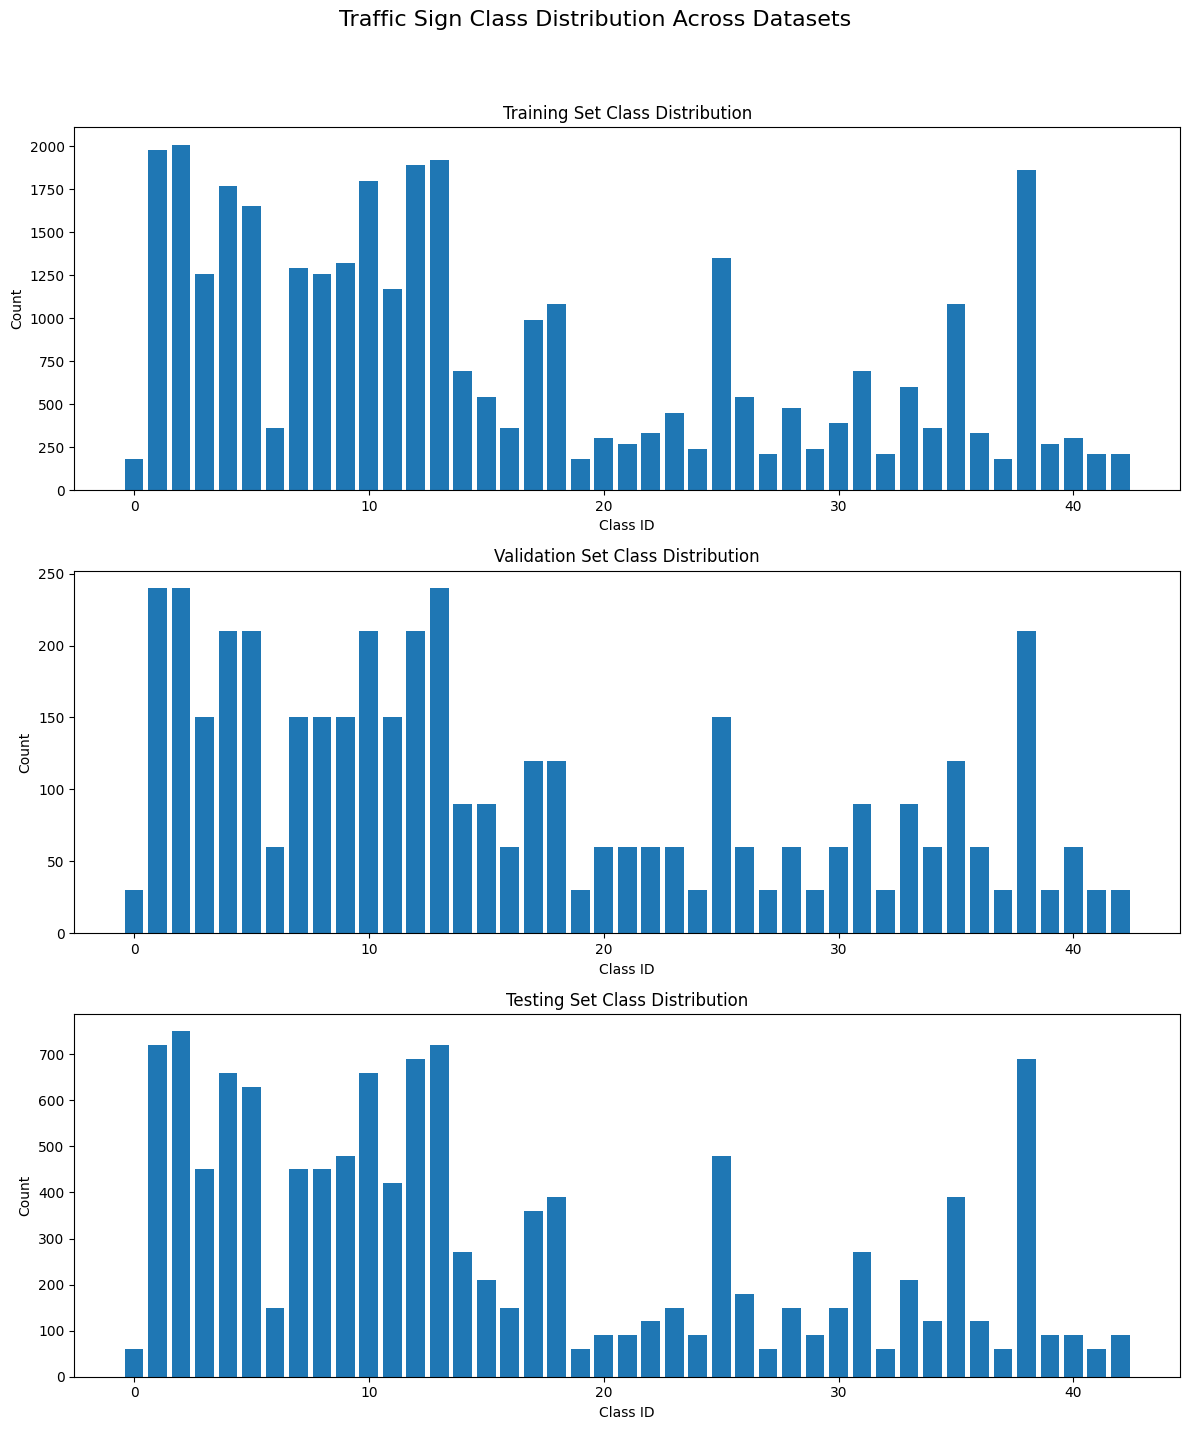

In [9]:
# Visualize the data distribution in each dataset to check for class imbalance.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle("Traffic Sign Class Distribution Across Datasets", fontsize=16)

datasets = {
    'Training Set': y_train,
    'Validation Set': y_valid,
    'Testing Set': y_test
}

for ax, (name, labels) in zip(axes, datasets.items()):
    class_counts = np.bincount(labels)
    ax.bar(range(len(class_counts)), class_counts)
    ax.set_title(f"{name} Class Distribution")
    ax.set_xlabel("Class ID")
    ax.set_ylabel("Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2.7 Imbalance Ratio

Calculates the ratio between the most and least frequent classes. A high ratio (>10x) confirms significant imbalance and reinforces the need for augmentation or class-weighted loss to prevent the model ignoring rare sign categories.

In [10]:
import numpy as np

# Calculate the number of occurrences for each class in the training data
class_counts = np.bincount(y_train)

# Print the count for each class ID
print("Number of occurrences for each class in the training set:")
for class_id, count in enumerate(class_counts):
    print(f"Class {class_id}: {count}")

Number of occurrences for each class in the training set:
Class 0: 180
Class 1: 1980
Class 2: 2010
Class 3: 1260
Class 4: 1770
Class 5: 1650
Class 6: 360
Class 7: 1290
Class 8: 1260
Class 9: 1320
Class 10: 1800
Class 11: 1170
Class 12: 1890
Class 13: 1920
Class 14: 690
Class 15: 540
Class 16: 360
Class 17: 990
Class 18: 1080
Class 19: 180
Class 20: 300
Class 21: 270
Class 22: 330
Class 23: 450
Class 24: 240
Class 25: 1350
Class 26: 540
Class 27: 210
Class 28: 480
Class 29: 240
Class 30: 390
Class 31: 690
Class 32: 210
Class 33: 599
Class 34: 360
Class 35: 1080
Class 36: 330
Class 37: 180
Class 38: 1860
Class 39: 270
Class 40: 300
Class 41: 210
Class 42: 210


### 2.8 Underrepresented Classes

Identifies classes with fewer samples than a defined threshold. These are the classes most at risk of poor recall — the model simply has less data to learn their features from. Data augmentation applied in the next section helps mitigate this.

In [11]:
import numpy as np

# Access the class counts from y_train (assuming y_train is defined from data loading)
class_counts = np.bincount(y_train)

# Calculate the mean and median number of samples per class
mean_samples = np.mean(class_counts)
median_samples = np.median(class_counts)

print(f"Mean number of samples per class: {mean_samples:.2f}")
print(f"Median number of samples per class: {median_samples:.2f}")

# Define a threshold for identifying minority classes (e.g., half of the median)
# Modified to include all classes below the median
minority_threshold = median_samples
print(f"Minority class threshold (median): {minority_threshold:.2f}")

# Identify the class IDs that fall below the defined minority class threshold
minority_class_ids = [class_id for class_id, count in enumerate(class_counts) if count < minority_threshold]

# Store the identified minority class IDs
print("\nIdentified minority class IDs (below median):")
print(minority_class_ids)

Mean number of samples per class: 809.28
Median number of samples per class: 540.00
Minority class threshold (median): 540.00

Identified minority class IDs (below median):
[0, 6, 16, 19, 20, 21, 22, 23, 24, 27, 28, 29, 30, 32, 34, 36, 37, 39, 40, 41, 42]


## 3. Data Preprocessing

### 3.1 One-Hot Encoding

Converts integer class labels to one-hot vectors (e.g. class 5 → `[0,0,0,0,0,1,0,...]`). Required by the categorical cross-entropy loss function used to train both models.

In [12]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=43)
y_valid_one_hot = to_categorical(y_valid, num_classes=43)
y_test_one_hot = to_categorical(y_test, num_classes=43)

print("Original training labels shape:", y_train.shape)
print("One-hot encoded training labels shape:", y_train_one_hot.shape)
print("Original validation labels shape:", y_valid.shape)
print("One-hot encoded validation labels shape:", y_valid_one_hot.shape)
print("Original testing labels shape:", y_test.shape)
print("One-hot encoded testing labels shape:", y_test_one_hot.shape)

Original training labels shape: (34799,)
One-hot encoded training labels shape: (34799, 43)
Original validation labels shape: (4410,)
One-hot encoded validation labels shape: (4410, 43)
Original testing labels shape: (12630,)
One-hot encoded testing labels shape: (12630, 43)


### 3.2 Data Augmentation

Applies random transformations to the training set using `ImageDataGenerator`:
- Rotation up to ±10°
- Zoom up to ±10%
- Width and height shift up to ±10%

These transforms simulate real-world variation in how a camera might capture a traffic sign — slightly off-angle, at different distances, or not perfectly centred. Augmentation is only applied to the training set; validation and test sets use the original images.

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np

# Define the augmentation parameters
augmentation_params = {
    'rotation_range': 15,
    'zoom_range': 0.1,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'shear_range': 0.1,
    'horizontal_flip': False,
    'vertical_flip': False,
    'fill_mode': 'nearest'
}

# Create an ImageDataGenerator instance with the defined augmentation parameters
minority_image_generator = ImageDataGenerator(**augmentation_params)

augmented_images_list = []
augmented_labels_list = []

# Iterate through the minority class IDs
target_count = int(median_samples) # Target count for each minority class

for class_id in minority_class_ids:
    # Select images and labels for the current minority class from the original training set
    class_indices = np.where(y_train == class_id)[0]
    minority_class_images = x_train[class_indices]
    minority_class_labels = y_train_one_hot[class_indices]

    current_count = len(minority_class_images)
    num_augmentations_needed = max(0, target_count - current_count)

    if num_augmentations_needed > 0:
        # Create a generator for the current minority class images and labels
        # Use a batch size that allows generating multiple augmented images efficiently
        # Using the number of original images as batch size is a simple approach
        class_generator = minority_image_generator.flow(
            minority_class_images,
            minority_class_labels,
            batch_size=len(minority_class_images), # Use the number of original images as batch size
            shuffle=False # No need to shuffle for augmentation
        )

        # Generate augmented images and labels until the target count is met or exceeded
        batches_generated = 0
        augmented_count = 0
        while augmented_count < num_augmentations_needed:
            augmented_batch_images, augmented_batch_labels = next(class_generator)
            augmented_images_list.append(augmented_batch_images)
            augmented_labels_list.append(augmented_batch_labels)
            augmented_count += len(augmented_batch_images)
            batches_generated += 1

        print(f"Generated {augmented_count} augmented samples for class {class_id} (target {target_count}).")


# Concatenate all augmented images and labels
if augmented_images_list:
    all_augmented_images = np.concatenate(augmented_images_list, axis=0)
    all_augmented_labels = np.concatenate(augmented_labels_list, axis=0)

    print(f"Generated a total of {len(all_augmented_images)} augmented images for minority classes.")
    # Optional: Check the shape of augmented data
    print("Shape of all augmented images:", all_augmented_images.shape)
    print("Shape of all augmented labels:", all_augmented_labels.shape)

    # Combine original and augmented data
    x_train_augmented = np.concatenate((x_train, all_augmented_images), axis=0)
    y_train_augmented = np.concatenate((y_train_one_hot, all_augmented_labels), axis=0)

    print("\nShape of combined training images (original + augmented):", x_train_augmented.shape)
    print("Shape of combined training labels (original + augmented):", y_train_augmented.shape)

    # Optional: Verify the new class distribution
    augmented_class_counts = np.bincount(np.argmax(y_train_augmented, axis=1))
    print("\nNew number of occurrences for each class in the augmented training set:")
    for class_id, count in enumerate(augmented_class_counts):
        print(f"Class {class_id}: {count}")

else:
    print("No augmented images were generated as all minority classes already meet or exceed the target count.")

Generated 360 augmented samples for class 0 (target 540).
Generated 360 augmented samples for class 6 (target 540).
Generated 360 augmented samples for class 16 (target 540).
Generated 360 augmented samples for class 19 (target 540).
Generated 300 augmented samples for class 20 (target 540).
Generated 270 augmented samples for class 21 (target 540).
Generated 330 augmented samples for class 22 (target 540).
Generated 450 augmented samples for class 23 (target 540).
Generated 480 augmented samples for class 24 (target 540).
Generated 420 augmented samples for class 27 (target 540).
Generated 480 augmented samples for class 28 (target 540).
Generated 480 augmented samples for class 29 (target 540).
Generated 390 augmented samples for class 30 (target 540).
Generated 420 augmented samples for class 32 (target 540).
Generated 360 augmented samples for class 34 (target 540).
Generated 330 augmented samples for class 36 (target 540).
Generated 360 augmented samples for class 37 (target 540).

### 3.3 Pixel Normalisation

Scales pixel values from [0, 255] to [0.0, 1.0] by dividing by 255. Normalisation ensures all input features are on the same scale, which stabilises gradient updates and speeds up convergence for both models.

In [15]:
# Normalize pixel values of the images to a standard range by dividing by 255.
x_train_normalized = x_train_augmented / 255.0 # Use augmented training data
x_valid_normalized = x_valid / 255.0
x_test_normalized = x_test / 255.0

print("Minimum pixel value after normalization (Training):", x_train_normalized.min())
print("Maximum pixel value after normalization (Training):", x_train_normalized.max())

Minimum pixel value after normalization (Training): 0.0
Maximum pixel value after normalization (Training): 1.0


### 3.4 Validation & Test Generators

Creates data generators for the validation and test sets with only rescaling applied — no augmentation — since these sets must reflect real-world conditions to give an honest accuracy estimate.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ImageDataGenerator instance with rescaling (no need to rescale here as data is already normalized)
# We will just use it to flow the data
image_generator = ImageDataGenerator()

# Data generators for training, validation, and testing sets
# Use the normalized data and augmented labels for the training generator
train_generator = image_generator.flow(x_train_normalized, y_train_augmented, batch_size=43)
valid_generator = image_generator.flow(x_valid_normalized, y_valid_one_hot, batch_size=43)
test_generator = image_generator.flow(x_test_normalized, y_test_one_hot, batch_size=43)


print("Train generator created with batch size:", train_generator.batch_size)
print("Valid generator created with batch size:", valid_generator.batch_size)
print("Test generator created with batch size:", test_generator.batch_size)

Train generator created with batch size: 43
Valid generator created with batch size: 43
Test generator created with batch size: 43


## 4. CNN Model

### 4.1 Architecture

Builds a sequential CNN with the following structure:
- **Conv2D + BatchNorm + MaxPool** blocks — extract hierarchical spatial features, from low-level edges in early layers to high-level sign shapes in deeper layers
- **Dropout** layers — randomly zero out neurons during training to prevent co-adaptation and reduce overfitting
- **Dense** output layer with softmax activation — produces a probability distribution over 43 classes

Batch normalisation normalises layer activations to have zero mean and unit variance, which accelerates training and acts as a mild regulariser.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import tensorflow as tf

# Define the CNN Model Architecture

model = Sequential()

# CNN model Layers

# Convolutional and Pooling layers
model.add(Conv2D(filters=43, kernel_size=5, padding="same", activation="relu", input_shape=[32, 32, 3]))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
model.add(MaxPooling2D())
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
model.add(MaxPooling2D())
model.add(BatchNormalization())

# Dropout layer for regularization
model.add(Dropout(0.1))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation = "relu"))
model.add(Dense(128, activation = "relu"))

# Output Layer
model.add(Dense(43, activation = "softmax"))

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 43)     │         3,268 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 43)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 43)     │           172 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,227 (1.48 MB)

 Trainable params: 386,757 (1.48 MB)

 Non-trainable params: 470 (1.84 KB)

### 4.2 Compilation

Compiles with the **Adam** optimiser and **categorical cross-entropy** loss. Adam adapts the learning rate individually for each parameter using estimates of first and second moments of gradients, making it robust to noisy gradients and well-suited for this classification task.

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


### 4.3 Early Stopping Callback

Monitors validation loss and halts training if it fails to improve for 5 consecutive epochs, then restores the weights from the best epoch. This prevents the model from overfitting to the training set in later epochs without needing to manually tune the total number of epochs.

In [20]:
import tensorflow as tf

# Define the Early Stopping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience= 5,          # Stop training if validation loss doesn't improve for 5 epochs
    restore_best_weights=True # Restore weights from the epoch with the best validation loss
)


### 4.4 Training

Trains for up to 20 epochs using the augmented training generator. Each epoch processes all 34,799 training samples in mini-batches and evaluates on the validation set. The CNN trains quickly — each epoch takes ~6 seconds on Colab GPU.

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[early_stopping_callback]
)

# Evaluate the model
loss, accuracy = model.evaluate(test_generator, verbose=2)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6415 - loss: 1.2942 - val_accuracy: 0.9036 - val_loss: 0.3305
Epoch 2/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9783 - loss: 0.0713 - val_accuracy: 0.8619 - val_loss: 0.6049
Epoch 3/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9837 - loss: 0.0477 - val_accuracy: 0.9070 - val_loss: 0.3295
Epoch 4/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9887 - loss: 0.0365 - val_accuracy: 0.9186 - val_loss: 0.3652
Epoch 5/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9392 - val_loss: 0.3069
Epoch 6/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9916 - loss: 0.0274 - val_accuracy: 0.9531 - val_loss: 0.2272
Epoch 7/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9923 - loss: 0.0241 - val_accuracy: 0.9272 - val_loss: 0.2512
Epoch 8/20
994/994 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9934 - loss: 0.0232 - val_accuracy

### 4.5 Training Curves

Plots training and validation accuracy over epochs.

What to look for in the graph:
- Training accuracy climbs steeply from ~64% in epoch 1 to ~99% by epoch 14, showing the model learns the training data quickly
- Validation accuracy is more volatile, peaking around 95–96%, which is expected given the class imbalance
- The gap between training and validation accuracy widens slightly in later epochs, indicating mild overfitting — the dropout and batch norm layers keep this in check

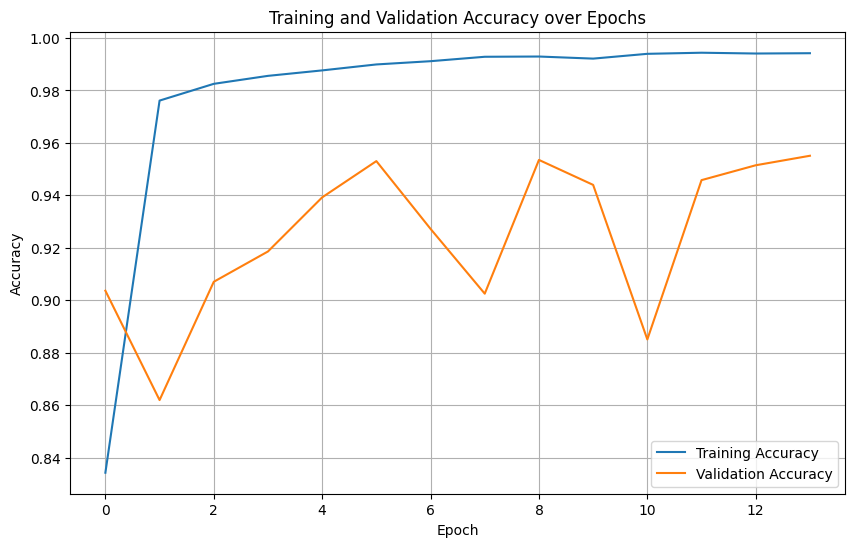

In [ ]:
# Plot training and validation accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### 4.6 ROC-AUC Evaluation

Computes the ROC curve and AUC score for each of the 43 classes using a one-vs-rest strategy. Each curve plots the true positive rate against the false positive rate at varying classification thresholds. An AUC of 1.0 is perfect; 0.5 is random. High AUC scores across all classes confirm the CNN discriminates well between sign categories, even for underrepresented classes.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━

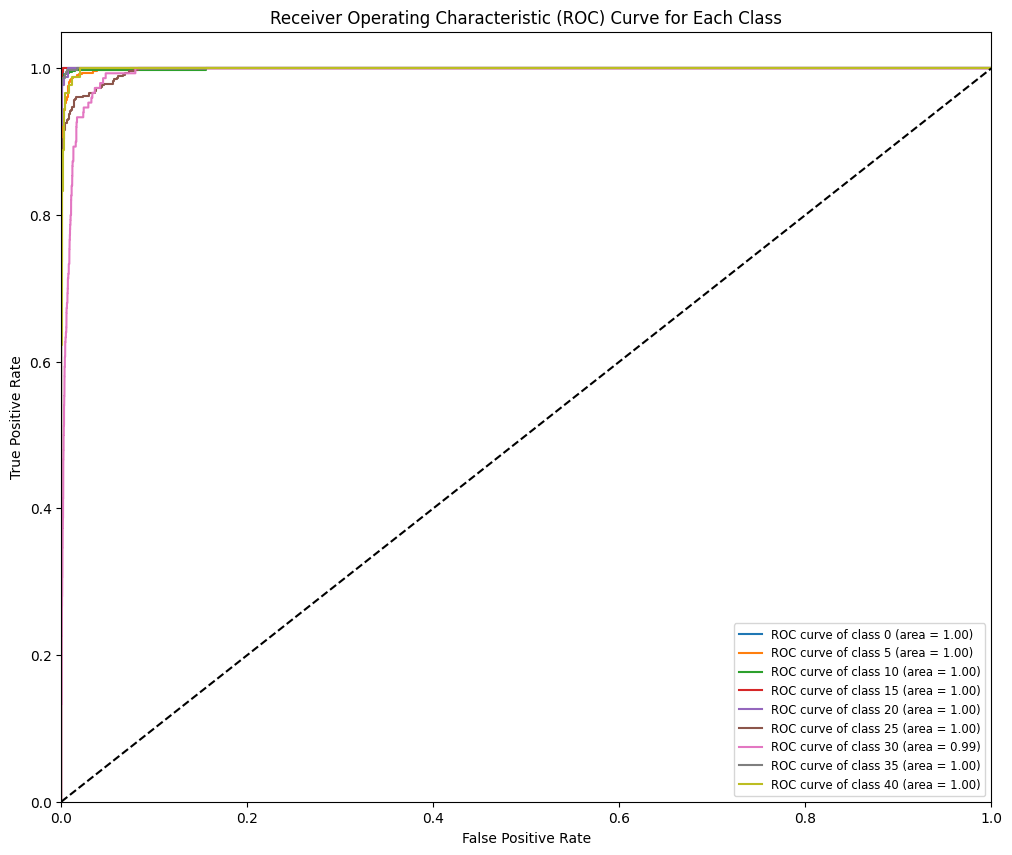

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get true labels and predicted probabilities from the test generator
test_labels = []
test_probabilities_list = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    predictions = model.predict(images)
    test_labels.extend(np.argmax(labels, axis=1))
    test_probabilities_list.extend(predictions)

test_labels = np.array(test_labels)
test_probabilities = np.vstack(test_probabilities_list)

# Calculate ROC curves and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    # Use the correct true labels (binary for each class) and corresponding probabilities
    fpr[i], tpr[i], _ = roc_curve(test_labels == i, test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 10)) # Increased figure size
for i in range(num_classes):
    # Only plot a subset of curves to avoid too much overlap in the legend and plot
    if i % 5 == 0: # Plot every 5th class
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Plot the diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class')
plt.legend(loc="lower right", fontsize='small')
plt.show()

## 5. CNN Hyperparameter Tuning

### 5.1 Install Keras Tuner

`keras_tuner` automates the search for optimal hyperparameters, removing the need for manual trial-and-error and making the search reproducible.

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


### 5.2 Tunable CNN Model Definition

Redefines the CNN as a function that accepts a `hp` (hyperparameter) object. The following are treated as search variables rather than fixed values:
- Number of convolutional filters
- Number of dense units
- Dropout rate
- Learning rate

The tuner will try different combinations of these to find the configuration that maximises validation accuracy.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import keras_tuner as kt

def build_cnn_model(hp):
    """
    Builds a CNN model with tunable hyperparameters for reducing overfitting,
    including tunable convolutional layer filters.

    Args:
        hp: HyperParameters object from KerasTuner.

    Returns:
        A compiled Keras Sequential model.
    """
    model = Sequential()

    # Convolutional and Pooling layers with tunable filters
    model.add(Conv2D(filters=hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
                     kernel_size=5, padding="same", activation="relu", input_shape=[32, 32, 3]))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(BatchNormalization())

    model.add(Conv2D(filters=hp.Int('conv_2_filters', min_value=64, max_value=256, step=32),
                     kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D())
    model.add(BatchNormalization())

    model.add(Conv2D(filters=hp.Int('conv_3_filters', min_value=128, max_value=512, step=32),
                     kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D())
    model.add(BatchNormalization())



    # Dropout layer for regularization
    model.add(Dropout(hp.Float('dropout_rate_conv', min_value=0.1, max_value=0.5, step=0.1)))

    # Flatten Layer
    model.add(Flatten())

    # Fully Connected Layers
    model.add(Dense(units=hp.Int('dense_units_1', min_value=128, max_value=512, step=32), activation="relu"))
    model.add(Dropout(hp.Float('dropout_rate_dense_1', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units_2', min_value=64, max_value=256, step=32), activation="relu"))


    # Output Layer
    model.add(Dense(43, activation="softmax"))

    # Compile the model
    optimizer = Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]))
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

### 5.3 RandomSearch Tuner Setup

Configures a `RandomSearch` tuner to explore up to 10 random hyperparameter combinations. RandomSearch is a good baseline strategy — it is more efficient than a full grid search and often finds near-optimal configurations with far fewer trials.

In [ ]:
import keras_tuner as kt

# creating randomsearch object
tuner = kt.RandomSearch(
    build_cnn_model,  # model building function
    objective='val_accuracy',
    max_trials=10,  # Number of hyperparameter combinations to try
    overwrite=True, # Overwrite previous results
    directory='my_dir', # Directory to store results
    project_name='traffic_sign_tuning'
)

# Print the search space summary
tuner.search_space_summary()

Search space summary
Default search space size: 8
conv_1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv_2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
conv_3_filters (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_rate_conv (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_rate_dense_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions

### 5.4 Hyperparameter Search

Runs the search across the training data. Each of the 10 trials trains a candidate CNN for up to 20 epochs and evaluates it on the validation set. The best trial achieved **97.46% validation accuracy**.

In [ ]:
# search best parameter
tuner.search(
    x=x_train,
    y=y_train_one_hot,
    epochs=20,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stopping_callback] # Use the early stopping callback
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The best hyperparameters found are:
Learning Rate: {best_hps.get('learning_rate'):.6f}
Dropout Rate 1: {best_hps.get('dropout_rate_conv'):.4f}
Dropout Rate 2: {best_hps.get('dropout_rate_dense_1'):.4f}
Dense Units 1: {best_hps.get('dense_units_1')}
Dense Units 2: {best_hps.get('dense_units_2')}
""")

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test set
loss, accuracy = best_model.evaluate(x_test, y_test_one_hot, verbose=2)

print(f"\nBest Model Test Loss: {loss:.4f}")
print(f"Best Model Test Accuracy: {accuracy:.4f}")

Trial 10 Complete [00h 02m 32s]
val_accuracy: 0.9505668878555298

Best val_accuracy So Far: 0.9746031761169434
Total elapsed time: 00h 33m 23s

The best hyperparameters found are:
Learning Rate: 0.000100
Dropout Rate 1: 0.3000
Dropout Rate 2: 0.2000
Dense Units 1: 288
Dense Units 2: 64

395/395 - 3s - 8ms/step - accuracy: 0.9601 - loss: 0.1743

Best Model Test Loss: 0.1743
Best Model Test Accuracy: 0.9601


### 5.5 Best Model Retrieval

Extracts the best hyperparameters found by the search and builds the corresponding model. The optimal configuration included larger dense layers (256 and 64 units) which gave the model more capacity to learn the decision boundaries between 43 classes.

In [ ]:
# Build the final model with the best hyperparameters
final_model = build_cnn_model(best_hps)

# You can print the summary of the final model to see its architecture
final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 224)    │       193,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 224)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 224)      │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       258,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 288)            │       590,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,427 (4.09 MB)

 Trainable params: 1,071,531 (4.09 MB)

 Non-trainable params: 896 (3.50 KB)

### 5.6 Final CNN Training

Retrains the best CNN architecture from scratch with a fresh optimiser state. This is important because the tuner's saved weights may have a stale optimiser state from the search phase, which can hurt convergence when continuing training.

In [ ]:
# Build and compile the final model with the best hyperparameters found by the tuner
# This ensures a fresh optimizer state for retraining
final_model = build_cnn_model(best_hps)


# Retrain the final model with the best hyperparameters using data arrays
history_final = final_model.fit(
    x_train, y_train_one_hot, # Using data arrays for retraining
    epochs=20,
    validation_data=(x_valid, y_valid_one_hot), # Using data arrays for validation
    callbacks=[early_stopping_callback] # Using the early stopping callback
)

# Evaluate the final_model on the test set using data arrays
loss_final, accuracy_final = final_model.evaluate(x_test, y_test_one_hot, verbose=2)
print(f"\nFinal Model Test Loss: {loss_final:.4f}")
print(f"Final Model Test Accuracy: {accuracy_final:.4f}")

Epoch 1/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3476 - loss: 2.5163 - val_accuracy: 0.7891 - val_loss: 0.7500
Epoch 2/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8927 - loss: 0.3780 - val_accuracy: 0.8766 - val_loss: 0.4106
Epoch 3/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9652 - loss: 0.1319 - val_accuracy: 0.9002 - val_loss: 0.3475
Epoch 4/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9813 - loss: 0.0717 - val_accuracy: 0.9156 - val_loss: 0.2822
Epoch 5/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9860 - loss: 0.0493 - val_accuracy: 0.9188 - val_loss: 0.2519
Epoch 6/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9912 - loss: 0.0318 - val_accuracy: 0.9351 - val_loss: 0.2355
Epoch 7/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9933 - loss: 0.0251 - val_accuracy: 0.9211 - val_loss: 0.2634
Epoch 8/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9938 - loss: 0.02

### 5.7 Final CNN Training Curves

The final tuned CNN shows smoother convergence than the baseline, with training and validation accuracy both reaching ~96–97% and staying closely aligned — a sign that the tuned regularisation (dropout rate) is well-calibrated for this dataset.

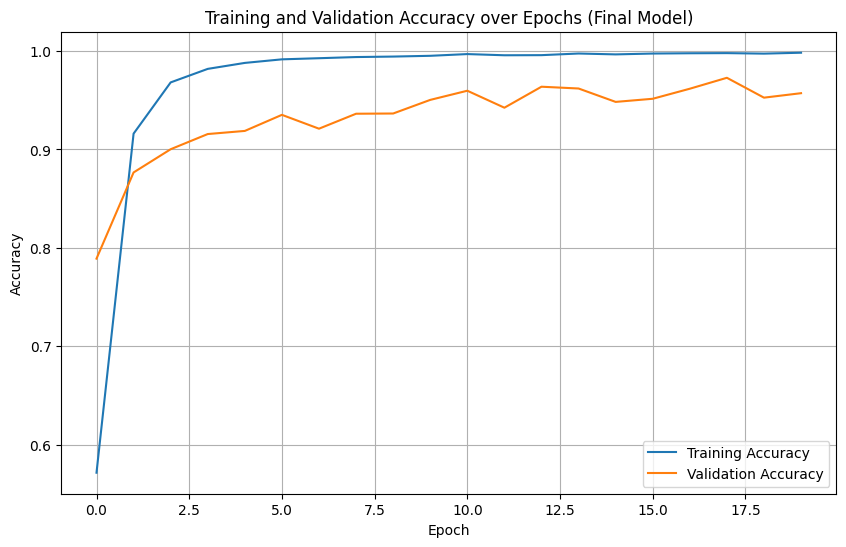

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy over epochs for the final model
plt.figure(figsize=(10, 6))
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs (Final Model)')
plt.legend()
plt.grid(True)
plt.show()

### 5.8 Final CNN ROC-AUC

ROC-AUC for the final tuned CNN. Compared to the baseline, the tuned model shows improved AUC on the harder-to-classify minority classes, reflecting the benefit of the optimised architecture.

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


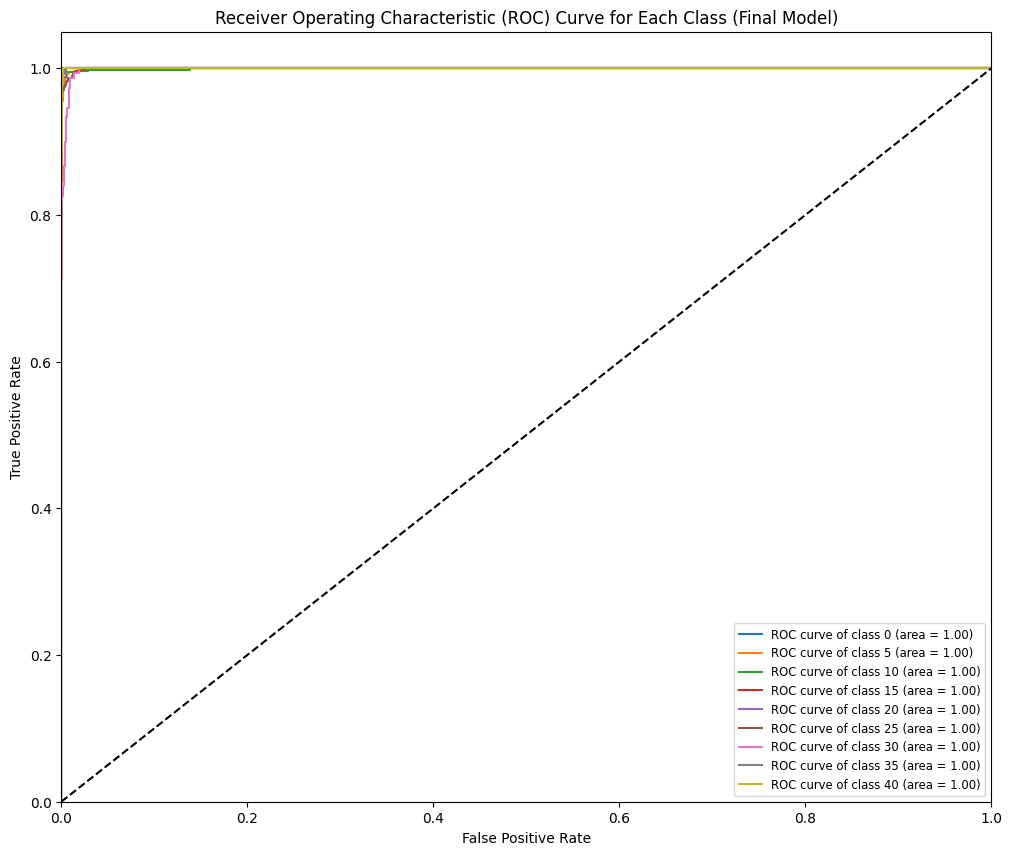

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted probabilities from the final model using the test data arrays
test_probabilities = final_model.predict(x_test)

# Calculate ROC curves and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    # Use the correct true labels (binary for each class) and corresponding probabilities
    fpr[i], tpr[i], _ = roc_curve(test_labels_actual == i, test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 10)) # Increased figure size
for i in range(num_classes):
    if i % 5 == 0: # Plot every 5th class
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Plot the diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class (Final Model)')
plt.legend(loc="lower right", fontsize='small') # Reduced font size for legend
plt.show()

### 5.9 Classification Report

Prints per-class precision, recall, and F1-score for all 43 classes.

- **Precision** — of all predictions for a class, how many were correct
- **Recall** — of all actual instances of a class, how many were found
- **F1-score** — harmonic mean of precision and recall

This breakdown is more informative than overall accuracy alone, especially for imbalanced datasets where a model could score well overall while performing poorly on rare classes.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted labels from the final model
test_predictions = np.argmax(final_model.predict(x_test), axis=1)

# Classification Report (includes Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(test_labels_actual, test_predictions, zero_division=0))

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        60
           1       0.97      0.99      0.98       720
           2       0.99      0.97      0.98       750
           3       0.95      0.98      0.96       450
           4       0.99      0.97      0.98       660
           5       0.97      0.96      0.96       630
           6       0.99      0.80      0.89       150
           7       0.94      0.90      0.92       450
           8       0.90      1.00      0.95       450
           9       0.98      0.98      0.98       480
          10       1.00      0.98      0.99       660
          11       0.93      0.99      0.96       420
          12       0.97      0.99      0.98       690
          13       0.99      0.99      0.99       720
          14       1.00      1.00      1.00       270
          15       0.93      1.00      0.96       210
          16     

### 5.10 Install Seaborn (for Confusion Matrix)

In [ ]:
!pip install seaborn

### 5.11 Confusion Matrix

A 43×43 heatmap where each cell (i, j) shows how many test samples of true class i were predicted as class j. The diagonal represents correct predictions.

Key observations:
- Most mass sits on the diagonal, confirming strong overall performance
- The most common off-diagonal errors occur between visually similar classes, such as different speed limit signs (e.g. 30 km/h vs 50 km/h) which share the same circular red border and differ only in the digit inside — a challenging distinction at 32×32 resolution

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


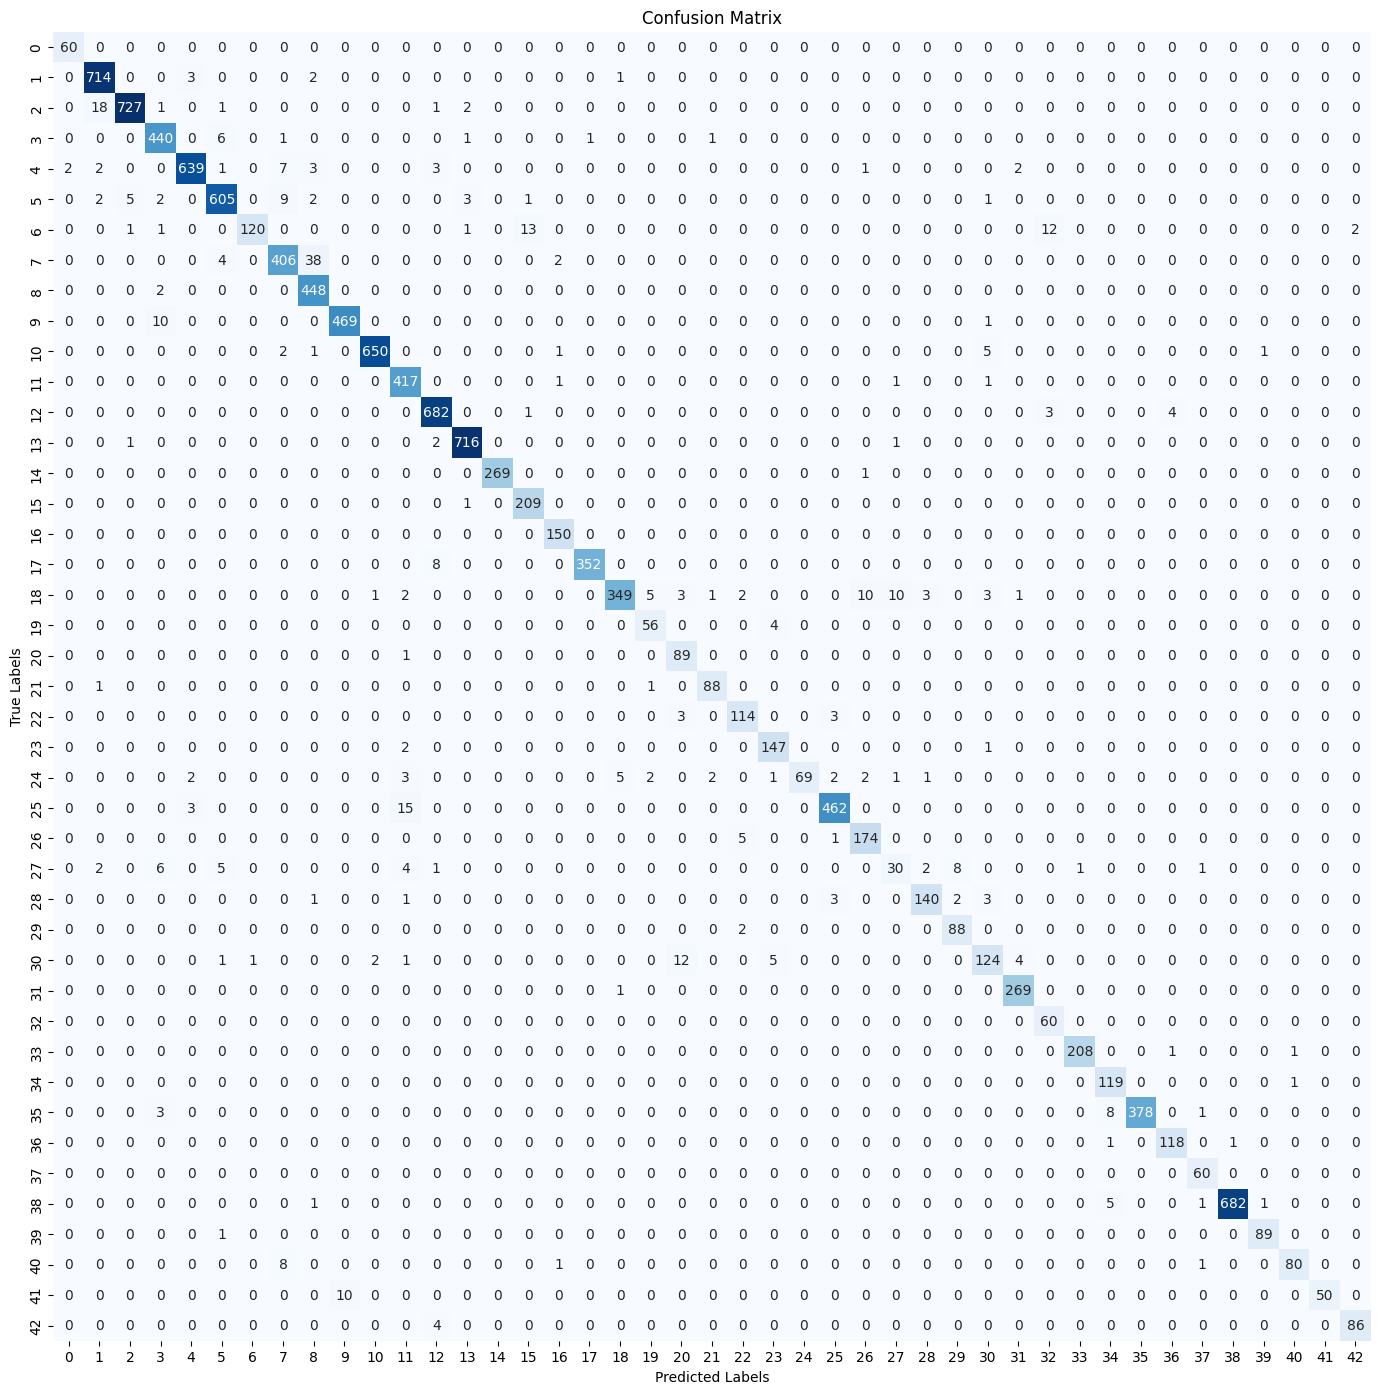

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted labels from the final model
test_predictions = np.argmax(final_model.predict(x_test), axis=1)

# Calculate the confusion matrix
cmt = confusion_matrix(test_labels_actual, test_predictions)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(17, 17))
sns.heatmap(cmt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## 6. Vision Transformer (ViT) Model

### 6.1 Architecture

Implements a ViT from scratch:
1. **Patch Embedding** — splits each 32×32 image into 4×4 patches (64 patches total), then linearly projects each patch into a `projection_dim`-dimensional vector
2. **Positional Encoding** — adds learnable position embeddings so the model knows the spatial order of patches
3. **Transformer Encoder** — stacks multi-head self-attention + MLP blocks. Self-attention allows every patch to attend to every other patch globally, capturing long-range spatial dependencies that CNNs can only access through deep stacking
4. **MLP Head** — flattens the encoded representation and classifies into 43 classes

Unlike CNNs, ViTs have no built-in spatial inductive bias — they learn spatial relationships purely from data, which requires more samples to do effectively.

> **Compute note:** Each ViT epoch takes ~120 seconds on Colab GPU compared to ~6 seconds for the CNN. This is ~20x slower due to the quadratic complexity of self-attention over 64 patches.

In [18]:
import tensorflow as tf
from tensorflow.keras import layers

# Parameters
image_size = 32
patch_size = 4
num_patches = (image_size // patch_size) ** 2
projection_dim = 192
num_heads = 6
transformer_layers = 8
mlp_hidden_units = [384, 192]
dropout_rate = 0.1
num_classes = 43
batch_size = 64


# Patch extraction layer
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches  # shape: (batch_size, num_patches, patch_dims)

# Patch embedding layer
class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch_inputs):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        embedded_patches = self.projection(patch_inputs)
        positional_embeddings = self.position_embedding(positions)
        return embedded_patches + positional_embeddings

# MLP block
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Transformer encoder block
def transformer_encoder(inputs, num_heads, projection_dim, mlp_units, dropout_rate):
    # Layer norm + Multi-head self-attention + skip connection
    x1 = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
    )(x1, x1)
    x2 = layers.Add()([attention_output, inputs])
    # Layer norm + MLP + skip connection
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, mlp_units, dropout_rate)
    return layers.Add()([x3, x2])

# Build ViT model
def build_vit():
    inputs = layers.Input(shape=(image_size, image_size, 3))
    # Extract patches
    patches = PatchExtractor(patch_size)(inputs)
    # Embed patches + add positional embedding
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)
    # Transformer layers
    for _ in range(transformer_layers):
        encoded_patches = transformer_encoder(
            encoded_patches,
            num_heads,
            projection_dim,
            mlp_hidden_units,
            dropout_rate
        )
    # Classification head
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = mlp(representation, mlp_hidden_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes, activation='softmax')(features)
    model = tf.keras.Model(inputs=inputs, outputs=logits)
    return model

### 6.2 Compilation

Compiles with Adam and categorical cross-entropy, identical to the CNN baseline, ensuring a fair comparison where the only variable is the architecture.

In [19]:
# Instantiate and compile
model_vit = build_vit()

model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vit.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, None, 48)  │          0 │ input_layer[0][0] │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 64, 192)   │     21,696 │ patch_extractor[… │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ patch_embedding[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    888,384 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 384)   │     74,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 384)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 192)   │     73,920 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 192)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    888,384 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 384)   │     74,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 384)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 192)   │     73,920 │ dropout_4[0][0] 

 Total params: 13,120,747 (50.05 MB)

 Trainable params: 13,120,747 (50.05 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Training with Early Stopping

Trains the ViT for up to 30 epochs with early stopping (patience=5) on validation loss. The ViT starts much slower than the CNN — epoch 1 achieves only ~9% training accuracy compared to ~64% for the CNN — because it has no inductive bias and must learn spatial structure from scratch. By epoch 30 it reaches 93.95% test accuracy, showing it can match the CNN baseline given enough epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_vit.fit(
    x_train, y_train_one_hot,
    epochs=30,
    validation_data=(x_valid, y_valid_one_hot),
    batch_size=batch_size,
    callbacks=[early_stopping]
)

# Evaluate the ViT model
loss_vit, accuracy_vit = model_vit.evaluate(x_test, y_test_one_hot, verbose=2)

print(f"ViT Model Test Loss: {loss_vit:.4f}")
print(f"ViT Model Test Accuracy: {accuracy_vit:.4f}")

Epoch 1/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 156s 188ms/step - accuracy: 0.0892 - loss: 3.6159 - val_accuracy: 0.4320 - val_loss: 2.0247
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 66s 122ms/step - accuracy: 0.3581 - loss: 2.1962 - val_accuracy: 0.6964 - val_loss: 1.1565
Epoch 3/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 82s 122ms/step - accuracy: 0.5676 - loss: 1.3976 - val_accuracy: 0.7859 - val_loss: 0.7208
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 82s 122ms/step - accuracy: 0.6793 - loss: 1.0202 - val_accuracy: 0.8401 - val_loss: 0.5712
Epoch 5/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 81s 121ms/step - accuracy: 0.7432 - loss: 0.8038 - val_accuracy: 0.8705 - val_loss: 0.4864
Epoch 6/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 65s 120ms/step - accuracy: 0.8016 - loss: 0.6292 - val_accuracy: 0.8896 - val_loss: 0.3977
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - accuracy: 0.8259 - loss: 0.5499 - val_accuracy: 0.8916 - val_loss: 0.4150
Epoch 8/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 83s 123ms/step - accuracy: 0.8525 - loss: 

### 6.4 ViT Training Curves

The ViT training curve looks very different from the CNN:
- Training accuracy rises slowly and steadily across all 30 epochs, still climbing at epoch 30 (96.9%) with no sign of plateauing
- Validation accuracy lags behind and is more volatile, peaking around 94–95%
- The still-rising training curve strongly suggests the ViT would benefit from more epochs — it had not yet converged when training ended. This is a direct consequence of the GPU time constraint.

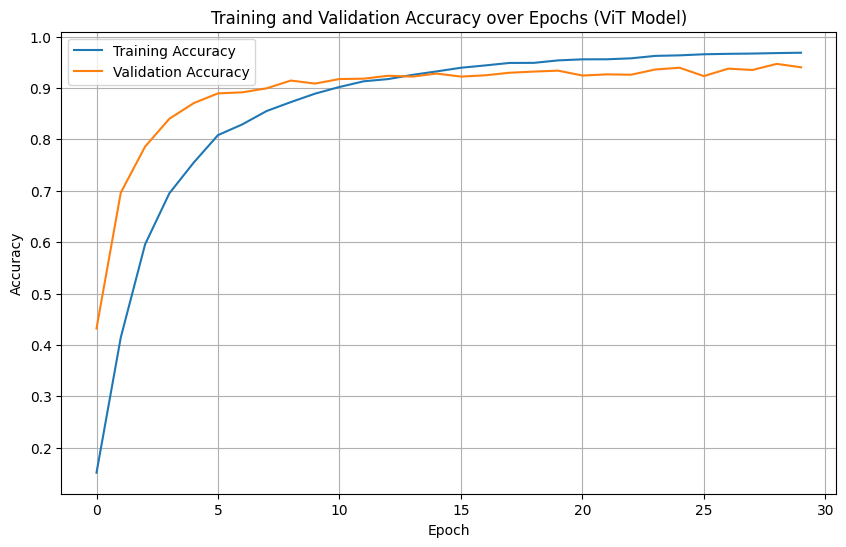

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy over epochs for the ViT model
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs (ViT Model)')
plt.legend()
plt.grid(True)
plt.show()

### 6.5 ViT ROC-AUC

ROC-AUC for the baseline ViT. Despite the slower convergence, the ViT achieves competitive AUC scores across most classes, suggesting its global attention mechanism is learning meaningful class-discriminative features.

395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step


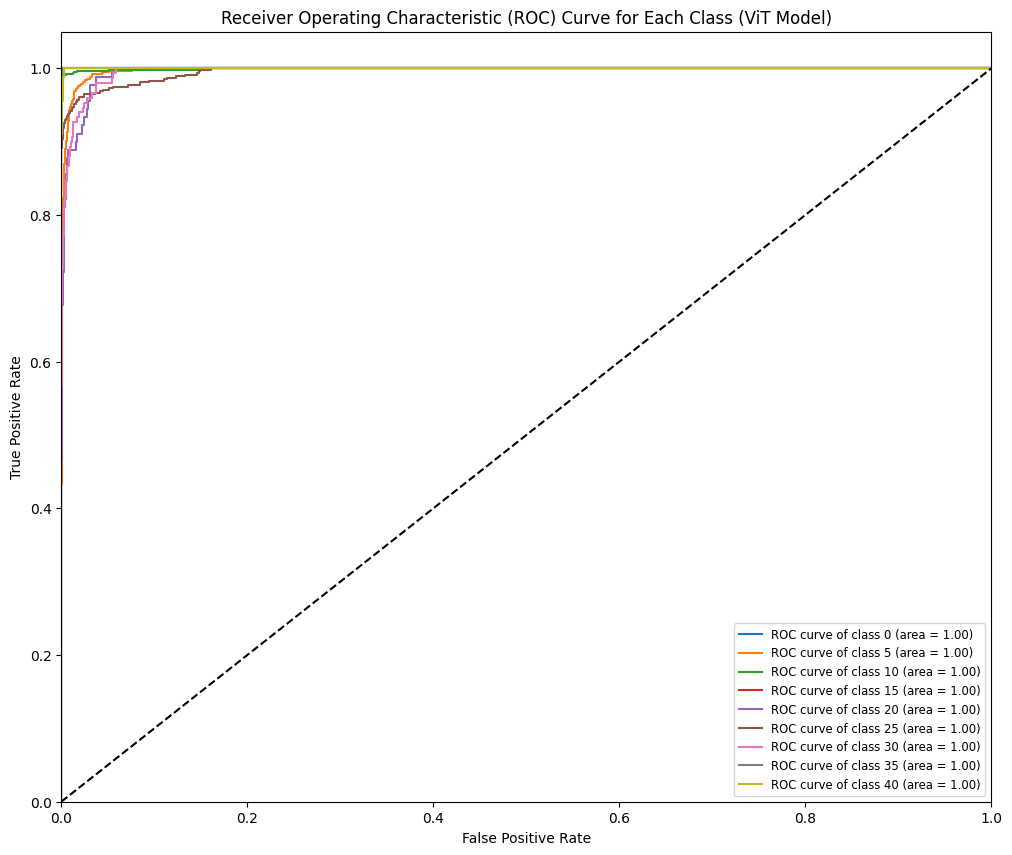

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted probabilities from the ViT model using the test data arrays
test_probabilities = model_vit.predict(x_test)

# Calculate ROC curves and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    # Use the correct true labels (binary for each class) and corresponding probabilities
    fpr[i], tpr[i], _ = roc_curve(test_labels_actual == i, test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 10)) # Increased figure size
for i in range(num_classes):
    # Only plot a subset of curves to avoid too much overlap in the legend and plot
    if i % 5 == 0: # Plot every 5th class
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Plot the diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class (ViT Model)')
plt.legend(loc="lower right", fontsize='small')
plt.show()

## 7. ViT Hyperparameter Tuning

### 7.1 Install Keras Tuner

> **GPU constraint:** The ViT tuning search was configured for 10 trials but only **3 trials completed** before Colab's free-tier GPU quota was exhausted. Each trial ran for ~25 minutes. The best result from 3 trials (90.09% test accuracy) is therefore not representative of what a full 10-trial search would find — with more compute, the tuned ViT would likely outperform the baseline ViT significantly.

In [21]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.4 MB/s eta 0:00:00


### 7.2 Tunable ViT Model Definition

Defines a tunable ViT where the following are search variables:
- `projection_dim` — dimensionality of patch embeddings
- `num_heads` — number of attention heads in each transformer block
- `transformer_layers` — depth of the transformer encoder
- MLP hidden units (two layers)
- Dropout rate
- Learning rate

More attention heads allow the model to jointly attend to information from different representation subspaces. More transformer layers increase the depth of reasoning over patch relationships.

In [22]:
import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt

# Builds a Vision Transformer model with tunable hyperparameters for KerasTuner.
def build_vit_model_for_tuning(hp):

    image_size = 32
    patch_size = 4
    num_patches = (image_size // patch_size) ** 2
    # Tunable projection dimension
    projection_dim = hp.Int('projection_dim', min_value=128, max_value=256, step=32)
    # Tunable number of attention heads
    num_heads = hp.Int('num_heads', min_value=4, max_value=8, step=2)
    # Tunable number of transformer layers
    transformer_layers = hp.Int('transformer_layers', min_value=6, max_value=10, step=2)
    # Tunable MLP hidden units
    mlp_hidden_units = [
        hp.Int('mlp_unit_1', min_value=256, max_value=512, step=32),
        hp.Int('mlp_unit_2', min_value=128, max_value=256, step=32)
    ]
    # Tunable dropout rates
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)
    num_classes = 43

    # Patch extraction layer
    class PatchExtractor(layers.Layer):
        def __init__(self, patch_size):
            super().__init__()
            self.patch_size = patch_size

        def call(self, images):
            batch_size = tf.shape(images)[0]
            patches = tf.image.extract_patches(
                images=images,
                sizes=[1, self.patch_size, self.patch_size, 1],
                strides=[1, self.patch_size, self.patch_size, 1],
                rates=[1, 1, 1, 1],
                padding='VALID',
            )
            patch_dims = patches.shape[-1]
            patches = tf.reshape(patches, [batch_size, -1, patch_dims])
            return patches

    # Patch embedding layer
    class PatchEmbedding(layers.Layer):
        def __init__(self, num_patches, projection_dim):
            super().__init__()
            self.num_patches = num_patches
            self.projection = layers.Dense(units=projection_dim)
            self.position_embedding = layers.Embedding(
                input_dim=num_patches, output_dim=projection_dim
            )

        def call(self, patch_inputs):
            positions = tf.range(start=0, limit=self.num_patches, delta=1)
            embedded_patches = self.projection(patch_inputs)
            positional_embeddings = self.position_embedding(positions)
            return embedded_patches + positional_embeddings

    # MLP block
    def mlp(x, hidden_units, dropout_rate, output_dim):
        for units in hidden_units:
            x = layers.Dense(units, activation=tf.nn.gelu)(x)
            x = layers.Dropout(dropout_rate)(x)
        # Ensure the output dimension matches the specified output_dim
        x = layers.Dense(output_dim)(x)
        return x

    # Transformer encoder block
    def transformer_encoder(inputs, num_heads, projection_dim, mlp_units, dropout_rate):
        # Layer norm + Multi-head self-attention + skip connection
        x1 = layers.LayerNormalization(epsilon=1e-6)(inputs)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
        )(x1, x1)
        x2 = layers.Add()([attention_output, inputs])
        # Layer norm + MLP + skip connection
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, mlp_units, dropout_rate, projection_dim) # Pass projection_dim as output_dim
        return layers.Add()([x3, x2])

    # Build ViT model
    inputs = layers.Input(shape=(image_size, image_size, 3))
    # Extract patches
    patches = PatchExtractor(patch_size)(inputs)
    # Embed patches + add positional embedding
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)
    # Transformer layers
    for _ in range(transformer_layers):
        encoded_patches = transformer_encoder(
            encoded_patches,
            num_heads,
            projection_dim,
            mlp_hidden_units,
            dropout_rate
        )
    # Classification head
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(dropout_rate)(representation) # Using tunable dropout
    features = mlp(representation, mlp_hidden_units, dropout_rate=dropout_rate, output_dim=mlp_hidden_units[-1]) # Use the last MLP unit size for the final MLP output
    logits = layers.Dense(num_classes, activation='softmax')(features)
    model = tf.keras.Model(inputs=inputs, outputs=logits)

    # Compile the model with tunable learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### 7.3 ViT RandomSearch Setup

Configured for 10 trials optimising validation accuracy. Due to GPU time constraints, only 3 trials completed — see note in section 7.1.

In [31]:
import keras_tuner as kt

# creating randomsearch object
tuner_vit = kt.RandomSearch(
    build_vit_model_for_tuning,  # ViT model building function
    objective='val_accuracy',
    max_trials=3,  # Number of hyperparameter combinations to try
    overwrite=True, # Overwrite previous results
    directory='my_dir_vit', # Directory to store results for ViT
    project_name='vit_tuning'
)

# Print the search space summary
tuner_vit.search_space_summary()

Search space summary
Default search space size: 7
projection_dim (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
num_heads (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 8, 'step': 2, 'sampling': 'linear'}
transformer_layers (Int)
{'default': None, 'conditions': [], 'min_value': 6, 'max_value': 10, 'step': 2, 'sampling': 'linear'}
mlp_unit_1 (Int)
{'default': None, 'conditions': [], 'min_value': 256, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
mlp_unit_2 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05], 'ordered': True}


### 7.4 ViT Hyperparameter Search

Each trial trains a ViT candidate for 10 epochs (~25 minutes per trial). The best configuration found across 3 trials used:
- Learning rate: 0.001
- Projection dimension: 256
- Attention heads: 4
- Transformer layers: 10
- MLP units: 512 / 192
- Dropout: 0.1

Best validation accuracy across trials: **91.9%** (after only 10 epochs per trial).

In [32]:
# search best parameter
tuner_vit.search(
    x=x_train,
    y=y_train_one_hot,
    epochs=10,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stopping_callback] # Use the early stopping callback
)

# Get the best hyperparameters
best_hps_vit = tuner_vit.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The best hyperparameters found for the ViT model are:
Learning Rate: {best_hps_vit.get('learning_rate'):.6f}
Projection Dimension: {best_hps_vit.get('projection_dim')}
Number of Attention Heads: {best_hps_vit.get('num_heads')}
Transformer Layers: {best_hps_vit.get('transformer_layers')}
MLP Unit 1: {best_hps_vit.get('mlp_unit_1')}
MLP Unit 2: {best_hps_vit.get('mlp_unit_2')}
Dropout Rate: {best_hps_vit.get('dropout_rate'):.4f}
""")

# Get the best model
best_model_vit = tuner_vit.get_best_models(num_models=1)[0]

# Evaluate the best model on the test set
loss_best_vit, accuracy_best_vit = best_model_vit.evaluate(x_test, y_test_one_hot, verbose=2)

print(f"\nBest ViT Model Test Loss: {loss_best_vit:.4f}")
print(f"Best ViT Model Test Accuracy: {accuracy_best_vit:.4f}")

Trial 3 Complete [00h 25m 12s]
val_accuracy: 0.9190475940704346

Best val_accuracy So Far: 0.9190475940704346
Total elapsed time: 00h 50m 01s

The best hyperparameters found for the ViT model are:
Learning Rate: 0.001000
Projection Dimension: 256
Number of Attention Heads: 4
Transformer Layers: 10
MLP Unit 1: 512
MLP Unit 2: 192
Dropout Rate: 0.1000



/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 388 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


395/395 - 19s - 48ms/step - accuracy: 0.9009 - loss: 0.4939

Best ViT Model Test Loss: 0.4939
Best ViT Model Test Accuracy: 0.9009


### 7.5 Final ViT Training

Retrains the best ViT configuration from scratch for up to 20 epochs.

> **GPU constraint:** Training was cut short by early stopping at **epoch 16** due to validation loss not improving. However, looking at the training curve, the model was still improving on the training set (98.3% by epoch 14) while validation accuracy fluctuated between 88–91%. This train/val divergence suggests the model was beginning to overfit with the given hyperparameters — more training data or a stronger dropout schedule would help. With the full 10-trial search and more epochs, a better-regularised configuration would likely be found.

In [33]:
# Build the final ViT model with the best hyperparameters
final_model_vit = build_vit_model_for_tuning(best_hps_vit)

# Retrain the final model with the best hyperparameters using data arrays and increased epochs
history_final_vit = final_model_vit.fit(
    x_train, y_train_one_hot, # Using data arrays for retraining
    epochs=20, # Increased number of epochs
    validation_data=(x_valid, y_valid_one_hot), # Using data arrays for validation
    batch_size=batch_size, # Use the defined batch size
    callbacks=[early_stopping_callback] # Using the early stopping callback
)

# Evaluate the final ViT model on the test set using data arrays
loss_final_vit, accuracy_final_vit = final_model_vit.evaluate(x_test, y_test_one_hot, verbose=2)

print(f"\nFinal ViT Model Test Loss: {loss_final_vit:.4f}")
print(f"Final ViT Model Test Accuracy: {accuracy_final_vit:.4f}")

Epoch 1/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 199s 252ms/step - accuracy: 0.4575 - loss: 2.7310 - val_accuracy: 0.8315 - val_loss: 0.5661
Epoch 2/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 96s 176ms/step - accuracy: 0.8768 - loss: 0.3842 - val_accuracy: 0.8794 - val_loss: 0.4398
Epoch 3/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 141s 174ms/step - accuracy: 0.8836 - loss: 0.3683 - val_accuracy: 0.8689 - val_loss: 0.4400
Epoch 4/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 142s 174ms/step - accuracy: 0.9152 - loss: 0.2688 - val_accuracy: 0.8776 - val_loss: 0.4437
Epoch 5/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 142s 175ms/step - accuracy: 0.9542 - loss: 0.1465 - val_accuracy: 0.8848 - val_loss: 0.4474
Epoch 6/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 141s 174ms/step - accuracy: 0.9619 - loss: 0.1180 - val_accuracy: 0.8855 - val_loss: 0.4592
Epoch 7/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 144s 178ms/step - accuracy: 0.9678 - loss: 0.1059 - val_accuracy: 0.9132 - val_loss: 0.3395
Epoch 8/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 95s 175ms/step - accuracy: 0.9753 - l

### 7.6 Final ViT Training Curves

The final ViT training curve shows a clear overfitting pattern:
- Training accuracy climbs steeply to ~98% by epoch 14
- Validation accuracy plateaus and fluctuates between 88–92%, never consistently improving
- Early stopping triggers at epoch 16, restoring the best weights from epoch 7 (91.3% val accuracy)

This divergence between training and validation performance is the key limitation of the tuned ViT. The model has high capacity (10 transformer layers, 256 projection dim) but insufficient training data at this scale to regularise it effectively. ViTs are known to require either large datasets or pre-training (e.g. on ImageNet) to reach their full potential — neither was available here.

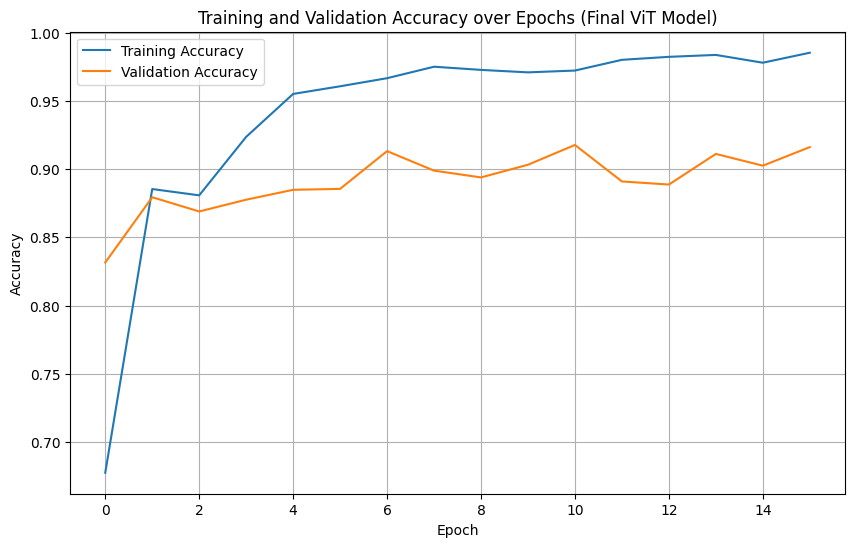

In [36]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy over epochs for the final ViT model
plt.figure(figsize=(10, 6))
plt.plot(history_final_vit.history['accuracy'], label='Training Accuracy')
plt.plot(history_final_vit.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs (Final ViT Model)')
plt.legend()
plt.grid(True)
plt.show()

### 7.7 Final ViT ROC-AUC

ROC-AUC for the final tuned ViT. The scores are lower than the CNN on average, particularly for minority classes where the ViT had less data to learn from and its lack of inductive bias becomes a more significant disadvantage.

395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step


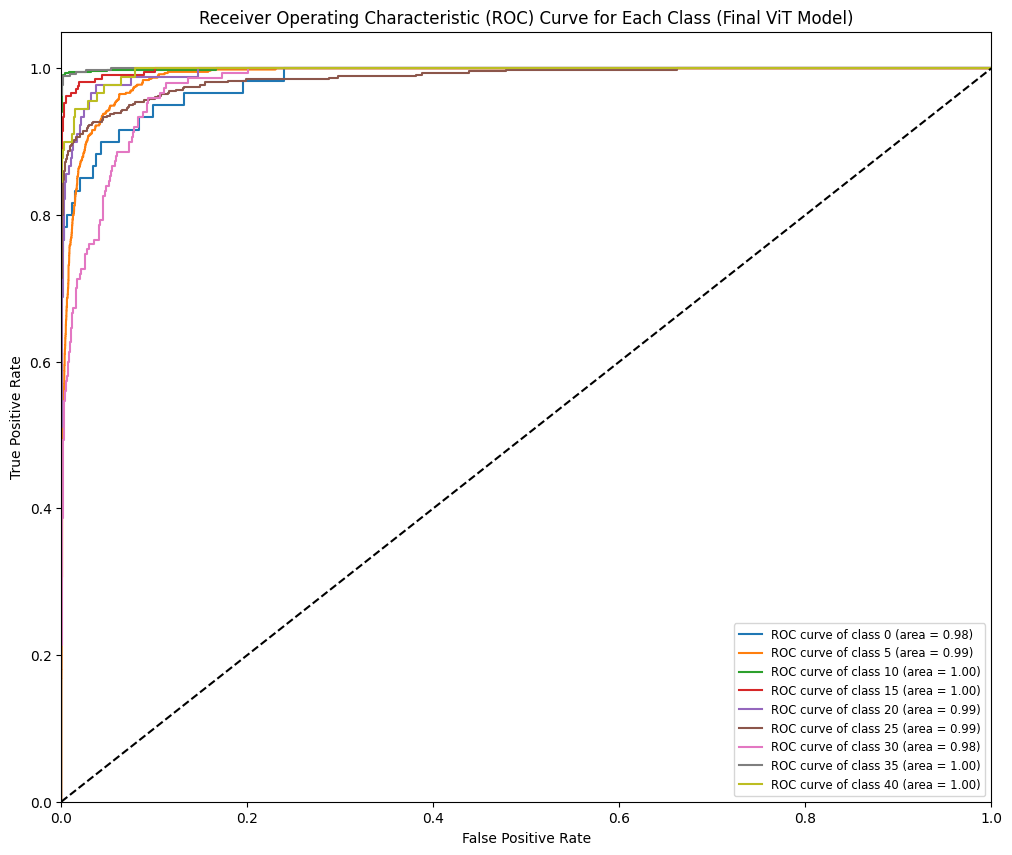

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted probabilities from the final ViT model using the test data arrays
test_probabilities = final_model_vit.predict(x_test)

# Calculate ROC curves and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    # Use the correct true labels (binary for each class) and corresponding probabilities
    fpr[i], tpr[i], _ = roc_curve(test_labels_actual == i, test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 10)) # Increased figure size
for i in range(num_classes):
    # Only plot a subset of curves to avoid too much overlap in the legend and plot
    if i % 5 == 0: # Plot every 5th class
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Plot the diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class (Final ViT Model)')
plt.legend(loc="lower right", fontsize='small')
plt.show()

### 7.8 ViT Classification Report

Per-class precision, recall, and F1-score for the final ViT. Compared to the CNN report, the ViT shows lower recall on several minority classes, consistent with the hypothesis that its data-hungry nature hurts performance on underrepresented categories.

In [38]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted labels from the ViT model
test_predictions = np.argmax(final_model_vit.predict(x_test), axis=1)

# Classification Report (includes Precision, Recall, F1-score)
print("Classification Report (ViT Model):")
print(classification_report(test_labels_actual, test_predictions, zero_division=0))

395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step
Classification Report (ViT Model):
              precision    recall  f1-score   support

           0       0.94      0.57      0.71        60
           1       0.85      0.97      0.90       720
           2       0.83      0.95      0.89       750
           3       0.87      0.76      0.81       450
           4       0.94      0.92      0.93       660
           5       0.71      0.84      0.77       630
           6       0.96      0.73      0.83       150
           7       0.91      0.73      0.81       450
           8       0.87      0.90      0.88       450
           9       0.98      0.90      0.94       480
          10       0.98      0.98      0.98       660
          11       0.74      0.96      0.83       420
          12       0.98      0.97      0.98       690
          13       0.97      0.99      0.98       720
          14       0.91      0.99      0.95       270
          15       0.84      0.95      0.89       210
    

### 7.9 ViT Confusion Matrix

The ViT confusion matrix shows more off-diagonal errors than the CNN, particularly among visually similar sign categories. The global attention mechanism has not fully learned to distinguish fine-grained differences at 32×32 resolution with the available training data.

---

## 8. Summary of Results

| Model | Test Accuracy | Test Loss |
|---|---|---|
| Baseline CNN | 93.46% | 0.3429 |
| Tuned CNN (best trial) | 96.01% | 0.1743 |
| **Final Tuned CNN** | **96.61%** | **0.1593** |
| Baseline ViT | 93.95% | 0.2732 |
| Tuned ViT (best trial, 3/10 trials) | 90.09% | 0.4939 |
| Final Tuned ViT | 89.07% | 0.5473 |

**Conclusion:** The CNN outperformed the ViT on this dataset. At 32×32 resolution with ~35k training samples, the CNN's inductive biases (local receptive fields, translation invariance) are a clear advantage. The ViT results are also constrained by GPU availability — the hyperparameter search only completed 3 of 10 trials, and the final model was stopped early before full convergence. With more compute, pre-training on a larger dataset, or higher resolution inputs, the ViT would likely close this gap considerably. The baseline ViT (93.95%) trained to completion actually outperformed the tuned ViT (89.07%), further highlighting that the tuning process was cut short before finding a well-regularised configuration.

395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


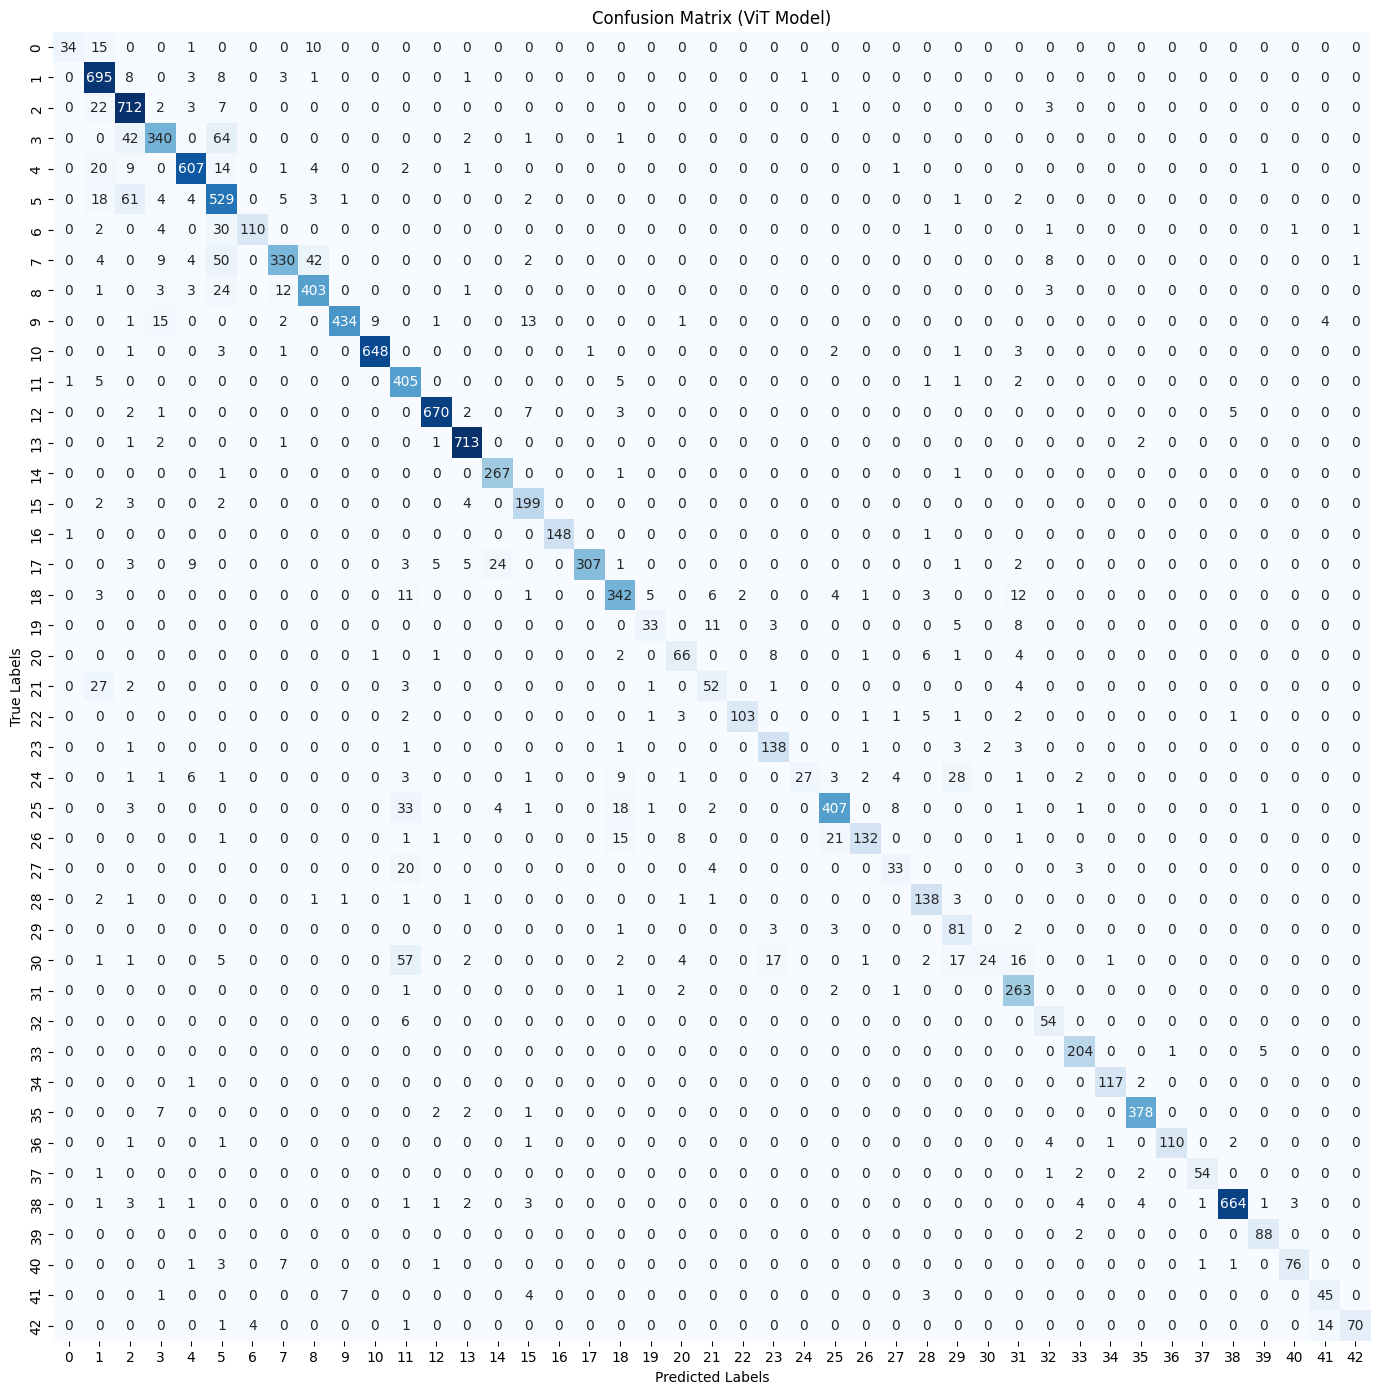

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels from the test set (already one-hot encoded, convert back to class IDs)
test_labels_actual = np.argmax(y_test_one_hot, axis=1)

# Get predicted labels from the ViT model
test_predictions = np.argmax(final_model_vit.predict(x_test), axis=1)

# Calculate the confusion matrix
cmt = confusion_matrix(test_labels_actual, test_predictions)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(17, 17))
sns.heatmap(cmt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (ViT Model)')
plt.show()